# Deep Learning for Biological Modeling
### SIAM Life Sciences 2026 Mini-Tutorial — Deep Learning Section

1. **MNIST 3 vs. 8 — MLP**: A simple neural network baseline
2. **MNIST 3 vs. 8 — CNN**: Spatial inductive bias + interpretability via Grad-CAM
3. **PneumoniaMNIST — CNN**: Same pipeline on real biomedical chest X-rays

Run in **Google Colab**: execute the setup cell first, then proceed top to bottom.


## Setup

Run the two cells below before anything else. The first installs `medmnist`;
the second imports all libraries used throughout the notebook.


In [1]:
!pip install medmnist -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndi
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
import medmnist
from medmnist import INFO

print("TensorFlow version:", tf.__version__)

/Users/suzanne/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


TensorFlow version: 2.20.0


---
## Part 1 — MNIST (3 vs. 8): Classification with a Simple Neural Network

We restrict MNIST to two visually similar classes — **3** and **8** — as a binary classification task.


### 1.1 Data splits: 60 / 20 / 20

We partition all available samples into three non-overlapping sets:

$$D = D_{\text{train}} \cup D_{\text{val}} \cup D_{\text{test}}, \qquad |\text{splits}| \approx 60\%\ /\ 20\%\ /\ 20\%$$

- **Train** (60 %): weights are updated on this set via backpropagation.
- **Validation** (20 %): evaluated at each epoch to monitor generalisation — never used to update weights.
- **Test** (20 %): fully held out. **All reported accuracies come from this set only.**

> *Note:* the partner session uses an 80/20 train/test split for classical ML. We introduce a three-way split here because deep networks have many more hyperparameters to tune, making a dedicated validation set essential — and because it lets us use **early stopping** (see §1.3).


In [3]:
(x_tr_full, y_tr_full), (x_te_full, y_te_full) = keras.datasets.mnist.load_data()

def filter_mnist(x, y, keep=(3, 8)):
    mask = (y == keep[0]) | (y == keep[1])
    return x[mask].astype("float32") / 255.0, (y[mask] == keep[1]).astype("float32")

x_all, y_all = map(np.concatenate, zip(
    filter_mnist(x_tr_full, y_tr_full),
    filter_mnist(x_te_full, y_te_full)
))

# Stratified 60 / 20 / 20
x_trainval, x_test,  y_trainval, y_test  = train_test_split(
    x_all, y_all, test_size=0.20, random_state=42, stratify=y_all)
x_train,    x_val,   y_train,    y_val   = train_test_split(
    x_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

print(f"Train:      {len(x_train):,}  |  Val: {len(x_val):,}  |  Test: {len(x_test):,} (held out)")


Train:      8,379  |  Val: 2,793  |  Test: 2,794 (held out)


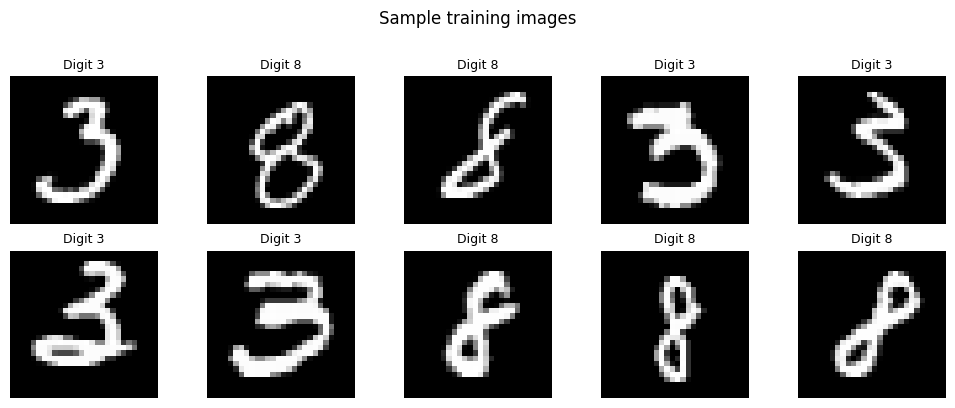

In [4]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
label_map = {0: "Digit 3", 1: "Digit 8"}
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap="gray"); ax.set_title(label_map[int(y_train[i])], fontsize=9); ax.axis("off")
plt.suptitle("Sample training images", y=1.01); plt.tight_layout(); plt.show()


### 1.2 Overfitting and Early Stopping

A central challenge in deep learning is **overfitting**: the model memorises training data and loses the ability to generalise. Formally, we distinguish:

$$L_{\text{train}}(\theta) = \frac{1}{|D_{\text{train}}|} \sum_{i \in D_{\text{train}}} \ell(f(x_i;\theta), y_i)$$
$$L_{\text{val}}(\theta) = \frac{1}{|D_{\text{val}}|} \sum_{i \in D_{\text{val}}} \ell(f(x_i;\theta), y_i)$$

Overfitting occurs when $L_{\text{train}}$ decreases while $L_{\text{val}}$ stagnates or increases — the **generalisation gap** $L_{\text{val}} - L_{\text{train}}$ widens. Intuitively, a sufficiently expressive model can fit any finite training set, but this does not imply it has learned the underlying distribution.

**Early stopping** is the simplest regularisation strategy: halt training at epoch $t^*$ where:

$$t^* = \arg\min_{t}\ L_{\text{val}}(\theta_t)$$

In practice we use a **patience** parameter $p$: stop if $L_{\text{val}}$ has not improved for $p$ consecutive epochs, and restore the weights from the best epoch. This avoids both underfitting (stopping too early) and overfitting (stopping too late).


In [5]:
# Early stopping callback — monitors validation loss
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=25,               # stop after 25 epochs with no improvement
    restore_best_weights=True,# revert to the epoch with lowest val_loss
    verbose=1
)
# We pass this to every model.fit() call below.

### 1.3 Multi-Layer Perceptron (MLP)

A single fully-connected layer maps $\mathbf{x} \in \mathbb{R}^n$ to $\mathbf{a} \in \mathbb{R}^m$ via:

$$\mathbf{a} = f\!\left(W\mathbf{x} + \mathbf{b}\right), \qquad W \in \mathbb{R}^{m \times n},\quad \mathbf{b} \in \mathbb{R}^m$$

Our two-layer network:
$$\mathbf{h} = \text{ReLU}(W_1 \mathbf{x} + \mathbf{b}_1), \quad W_1 \in \mathbb{R}^{16 \times 784}$$
$$\hat{y} = \sigma(\mathbf{w}_2^\top \mathbf{h} + b_2), \quad \mathbf{w}_2 \in \mathbb{R}^{16}$$

Training minimises the binary cross-entropy:

$$L(\theta) = -\frac{1}{N}\sum_{i=1}^{N}\left[y_i \log \hat{y}_i + (1-y_i)\log(1-\hat{y}_i)\right]$$

via mini-batch SGD with the Adam optimiser (adaptive first-order method, $\eta = 0.001$ by default). We run up to 50 epochs, with early stopping on $L_{\text{val}}$.


In [6]:
def build_mlp():
    model = models.Sequential([
        layers.Flatten(input_shape=(28, 28)),
        layers.Dense(16, activation="relu"),
        layers.Dense(1,  activation="sigmoid"),
    ], name="MLP")
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

mlp = build_mlp()
mlp.summary()

/Users/suzanne/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "MLP"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,577 (49.13 KB)

 Trainable params: 12,577 (49.13 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
mlp_history = mlp.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8549 - loss: 0.3699 - val_accuracy: 0.9620 - val_loss: 0.1149
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 530us/step - accuracy: 0.9633 - loss: 0.1154 - val_accuracy: 0.9681 - val_loss: 0.0927
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 507us/step - accuracy: 0.9679 - loss: 0.0978 - val_accuracy: 0.9696 - val_loss: 0.0844
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 502us/step - accuracy: 0.9738 - loss: 0.0828 - val_accuracy: 0.9735 - val_loss: 0.0765
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 525us/step - accuracy: 0.9736 - loss: 0.0811 - val_accuracy: 0.9760 - val_loss: 0.0688
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 548us/step - accuracy: 0.9764 - loss: 0.0734 - val_accuracy: 0.9785 - val_loss: 0.0644
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 536us/step - accuracy: 0.9798 - loss: 0.0664 - val_accuracy: 0.9803 - val_loss: 0.0585
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 532us/step - accuracy: 0.9834 - loss: 0.0599 - va

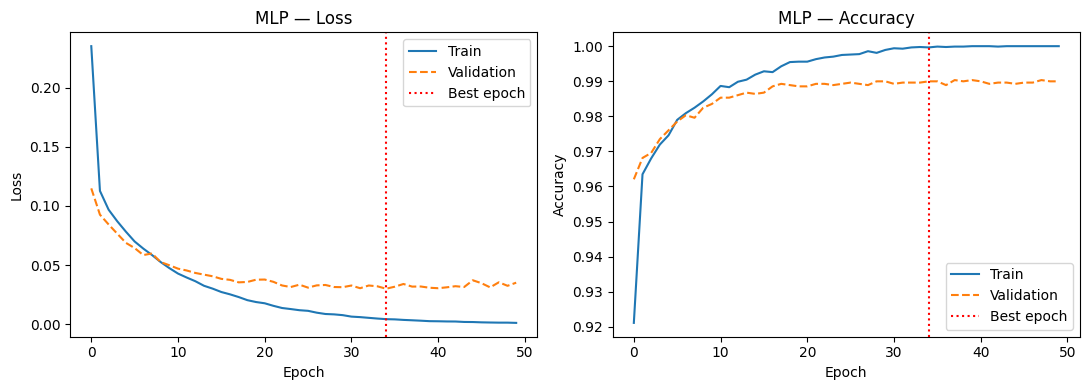

MLP test accuracy (held-out 20%): 0.9885


In [8]:
best_epoch_mlp = int(np.argmin(mlp_history.history['val_loss']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, ylabel in zip(axes, ['loss', 'accuracy'], ['Loss', 'Accuracy']):
    ax.plot(mlp_history.history[metric],          label='Train')
    ax.plot(mlp_history.history[f'val_{metric}'], label='Validation', linestyle='--')
    ax.axvline(best_epoch_mlp, color='red', linestyle=':', linewidth=1.5, label='Best epoch')
    ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel)
    ax.set_title(f'MLP — {ylabel}')
    ax.legend()
plt.tight_layout(); plt.show()

mlp_loss, mlp_acc = mlp.evaluate(x_test, y_test, verbose=0)
print(f'MLP test accuracy (held-out 20%): {mlp_acc:.4f}')


---
## Part 2 — MNIST (3 vs. 8): CNN + Interpretability (Grad-CAM)

The MLP treats each image as a vector in $\mathbb{R}^{784}$, discarding spatial structure entirely. A **Convolutional Neural Network** instead encodes a *spatial inductive bias* by applying learned filters locally across the image.


### 2.1 Convolutional Layer

A **filter** $W \in \mathbb{R}^{k \times k}$ slides over every local patch of the image,
producing one output per location — a **feature map**. With $C$ filters we get $C$ feature maps in parallel.

For each patch $X^{(k)}$ at position $k$:
$$F_k = f\!\left(\langle W, X^{(k)} \rangle + b\right)$$

Our architecture:

| Layer | Output shape | Parameters |
|-------|-------------|------------|
| Input (28×28, flattened+reshaped) | 28×28×1 | 0 |
| Conv2D (16 filters, 3×3, ReLU) | 28×28×16 | 160 |
| Flatten | 12,544 | 0 |
| Dense(1, sigmoid) | 1 | 12,545 |
| **Total** | | **12,705** |

This is comparable to the MLP (12,577 parameters) — the difference is **where** the parameters live:
the CNN learns 16 spatial filters; the MLP connects every pixel to every hidden node.


In [9]:
def build_cnn(input_shape=(28, 28)):
    model = models.Sequential([
        layers.Reshape((28, 28, 1), input_shape=input_shape),
        layers.Conv2D(16, (3,3), activation='relu', padding='same', name='conv1'),
        layers.Flatten(),
        layers.Dense(1, activation='sigmoid'),
    ], name='CNN')
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

cnn = build_cnn()
cnn.summary()


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ reshape (Reshape)               │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1 (Conv2D)                  │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12544)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │        12,545 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,705 (49.63 KB)

 Trainable params: 12,705 (49.63 KB)

 Non-trainable params: 0 (0.00 B)

In [10]:
cnn_history = cnn.fit(
    x_train, y_train,
    validation_data=(x_val, y_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)


Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9047 - loss: 0.2945 - val_accuracy: 0.9724 - val_loss: 0.0854
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9712 - loss: 0.0868 - val_accuracy: 0.9789 - val_loss: 0.0634
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9807 - loss: 0.0647 - val_accuracy: 0.9853 - val_loss: 0.0491
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9877 - loss: 0.0551 - val_accuracy: 0.9885 - val_loss: 0.0419
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9896 - loss: 0.0417 - val_accuracy: 0.9889 - val_loss: 0.0338
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9901 - loss: 0.0372 - val_accuracy: 0.9903 - val_loss: 0.0294
Epoch 7/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9929 - loss: 0.0276 - val_accuracy: 0.9910 - val_loss: 0.0274
Epoch 8/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9930 - loss: 0.0242 - val_accuracy: 0.

MLP test accuracy (held-out 20%): 0.9885
CNN test accuracy (held-out 20%): 0.9932


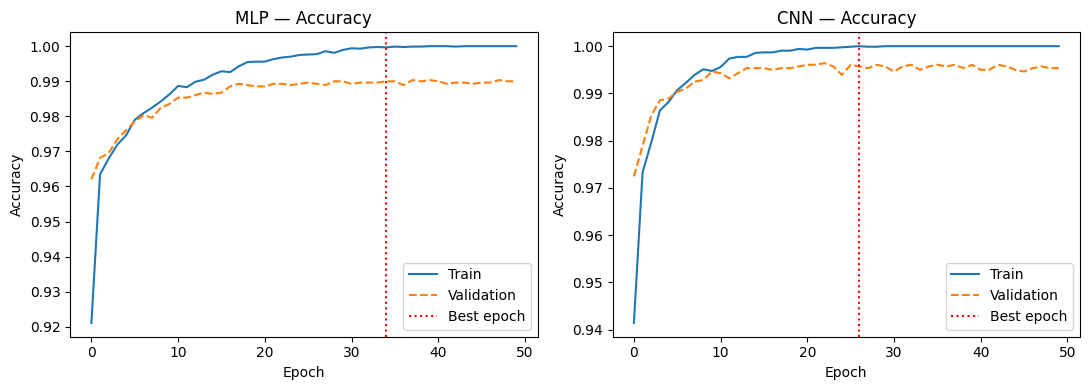

In [11]:
cnn_loss, cnn_acc = cnn.evaluate(x_test, y_test, verbose=0)
print(f'MLP test accuracy (held-out 20%): {mlp_acc:.4f}')
print(f'CNN test accuracy (held-out 20%): {cnn_acc:.4f}')

best_epoch_cnn = int(np.argmin(cnn_history.history['val_loss']))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, hist, title, best in zip(
    axes,
    [mlp_history, cnn_history],
    ['MLP', 'CNN'],
    [best_epoch_mlp, best_epoch_cnn]
):
    ax.plot(hist.history['accuracy'],     label='Train')
    ax.plot(hist.history['val_accuracy'], label='Validation', linestyle='--')
    ax.axvline(best, color='red', linestyle=':', linewidth=1.5, label='Best epoch')
    ax.set_title(f'{title} — Accuracy')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Accuracy')
    ax.legend()
plt.tight_layout(); plt.show()

### 2.2 Interpretability: Grad-CAM

**Grad-CAM** (Selvaraju et al. 2017) produces a spatial heatmap of which image regions
most influenced the prediction.

Let $A^k \in \mathbb{R}^{H \times W}$ be the $k$-th feature map of the convolutional layer,
and $y^c$ the score for class $c$. The importance weight of map $k$ is:

$$\alpha_k^c = \frac{1}{HW} \sum_{i=1}^{H}\sum_{j=1}^{W} \frac{\partial y^c}{\partial A^k_{ij}}$$

The heatmap is the ReLU of the weighted sum over all $K$ feature maps:

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\!\left(\sum_{k=1}^{K} \alpha_k^c\, A^k\right) \in \mathbb{R}^{H \times W}$$

Because we use `padding='same'` and no pooling, `conv1` outputs $28 \times 28 \times 16$ —
the same spatial resolution as the input.
A **smoothed** version applies a Gaussian kernel $G_\sigma$:

$$L^c_{\text{smooth}} = G_\sigma * L^c_{\text{Grad-CAM}}$$


In [12]:
def grad_cam(model, image, last_conv_layer='conv1'):
    """
    Grad-CAM: computes a heatmap of which spatial locations
    most influenced the prediction, using gradients of the
    output w.r.t. the last conv layer's feature maps.
    """
    img_tensor = tf.cast(image[np.newaxis, ...], tf.float32)

    layer_names = [l.name for l in model.layers]
    target_idx  = layer_names.index(last_conv_layer)

    with tf.GradientTape() as tape:
        x = img_tensor
        conv_out = None
        for i, layer in enumerate(model.layers):
            x = layer(x)
            if i == target_idx:
                conv_out = x
                tape.watch(conv_out)
        predictions = x
        loss = predictions[0, 0]

    grads       = tape.gradient(loss, conv_out)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    heatmap = tf.reduce_sum(conv_out[0] * pooled_grads, axis=-1).numpy()
    heatmap = np.maximum(heatmap, 0)
    if heatmap.max() > 0:
        heatmap /= heatmap.max()

    zoom = (image.shape[0] / heatmap.shape[0], image.shape[1] / heatmap.shape[1])
    return ndi.zoom(heatmap, zoom)


def smooth_cam(heatmap, sigma=2):
    """Gaussian-smooth the heatmap: G_sigma * L."""
    return ndi.gaussian_filter(heatmap, sigma=sigma)


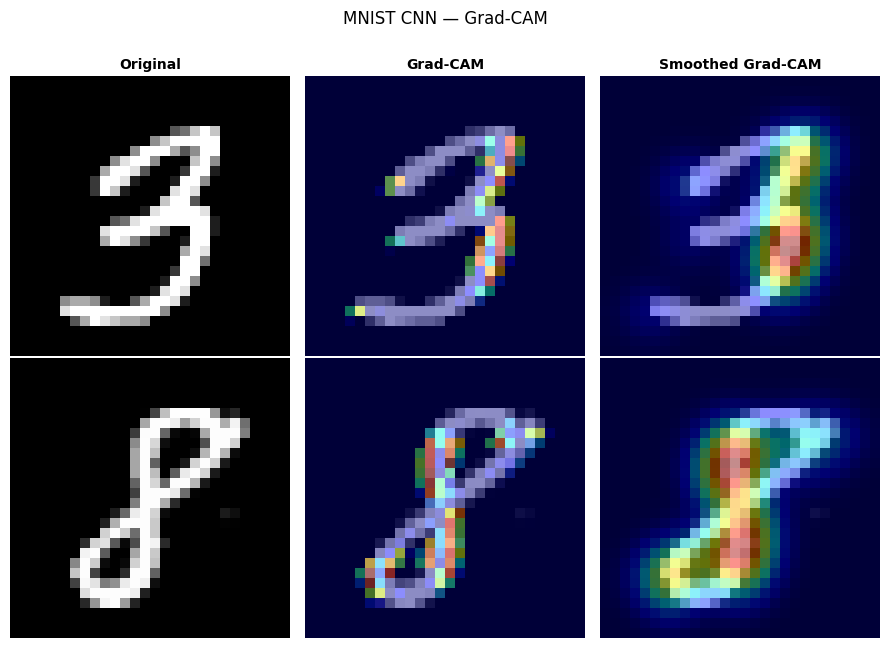

In [13]:
def visualise_cam(model, images, labels, indices, label_map, title_prefix=''):
    fig, axes = plt.subplots(len(indices), 3, figsize=(9, 3.2 * len(indices)))
    if len(indices) == 1:
        axes = axes[np.newaxis, :]
    for ax, ct in zip(axes[0], ['Original', 'Grad-CAM', 'Smoothed Grad-CAM']):
        ax.set_title(ct, fontsize=10, fontweight='bold')
    for row, idx in enumerate(indices):
        img = images[idx]
        cam        = grad_cam(model, img)
        cam_smooth = smooth_cam(cam)
        axes[row, 0].imshow(img, cmap='gray')
        axes[row, 0].set_ylabel(label_map[int(labels[idx])], fontsize=9)
        for col, hm in enumerate([cam, cam_smooth], start=1):
            axes[row, col].imshow(img, cmap='gray')
            axes[row, col].imshow(hm, cmap='jet', alpha=0.45)
        for ax in axes[row]: ax.axis('off')
    plt.suptitle(f'{title_prefix}Grad-CAM', y=1.01)
    plt.tight_layout(); plt.show()

idx_3 = np.where(y_test == 0)[0][5]
idx_8 = np.where(y_test == 1)[0][5]
label_map_mnist = {0: 'Digit 3', 1: 'Digit 8'}

visualise_cam(cnn, x_test, y_test,
              indices=[idx_3, idx_8],
              label_map=label_map_mnist,
              title_prefix='MNIST CNN — ')


**Interpreting the heatmaps:**

- **Digit 3 (top row):** The heatmap activates strongly along the ink strokes,
  particularly the right side where the two open arcs curve.
  This is the key distinguishing feature of a 3 — the model has learned to look
  for the open-arc structure that separates 3 from 8.

- **Digit 8 (bottom row):** Activation is very faint and diffuse — almost nothing.
  This is not a bug. With a single sigmoid output, the network learned to detect
  *3-ness*. The absence of that signal is how it classifies 8s.
  This asymmetry is typical in binary sigmoid classification.

- **Compare to an MLP:** An MLP Grad-CAM would scatter activation across
  disconnected pixels with no spatial coherence — a direct consequence of
  discarding the image's 2D structure by flattening.


---
## Part 3 — PneumoniaMNIST: Interpretability in Medical Imaging

We apply the **identical architecture and Grad-CAM pipeline** to a real biomedical dataset.

**PneumoniaMNIST** (MedMNIST v2; Yang et al. 2023) contains pediatric chest X-rays downsampled to $28 \times 28$, labelled Normal ($y=0$) or Pneumonia ($y=1$). The dataset provides its own train/val/test splits.

The central question is no longer only accuracy, but: **does the network attend to clinically relevant anatomy?**


### 3.1 Load and preview

In [14]:
DataClass = getattr(medmnist, INFO['pneumoniamnist']['python_class'])

splits = {}
for split in ('train', 'val', 'test'):
    ds = DataClass(split=split, download=True)
    imgs   = np.array([item[0] for item in ds], dtype="float32") / 255.0
    labels = np.array([item[1][0] for item in ds], dtype="float32")
    splits[split] = (imgs.squeeze(), labels)

x_pneu_train, y_pneu_train = splits['train']
x_pneu_val,   y_pneu_val   = splits['val']
x_pneu_test,  y_pneu_test  = splits['test']

total = sum(len(v[0]) for v in splits.values())
for name, (x, y) in splits.items():
    print(f"{name:6s}: {len(x):,} ({100*len(x)/total:.0f}%)  "
          f"Normal: {(y==0).sum()}  Pneumonia: {(y==1).sum()}")


train : 4,708 (80%)  Normal: 1214  Pneumonia: 3494
val   : 524 (9%)  Normal: 135  Pneumonia: 389
test  : 624 (11%)  Normal: 234  Pneumonia: 390


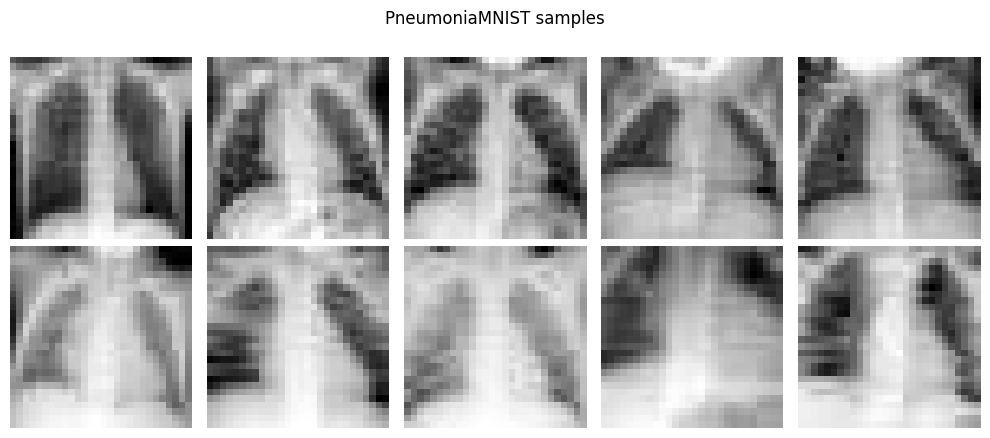

In [15]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4.5))
label_map_pneu = {0: "Normal", 1: "Pneumonia"}
for row, (cls, title) in enumerate([(0, "Normal"), (1, "Pneumonia")]):
    for col, idx in enumerate(np.where(y_pneu_train == cls)[0][:5]):
        ax = axes[row, col]
        ax.imshow(x_pneu_train[idx], cmap="gray")
        if col == 0: ax.set_ylabel(title, fontsize=10)
        ax.axis("off")
plt.suptitle("PneumoniaMNIST samples"); plt.tight_layout(); plt.show()


### 3.2 Train the CNN (same architecture)

We call `build_cnn()` without modification. What changes between Part 2 and Part 3 is entirely contained in the learned weight matrices $\theta = \{W_\ell, \mathbf{b}_\ell\}_\ell$ — the functional form $f(\cdot;\theta)$ is identical.

> **Class imbalance note:** pneumonia cases outnumber normals roughly 3:1. For a tutorial we accept this without correction; in practice one would use class-weighted loss or oversampling. The imbalance means raw accuracy can be misleading — a model predicting "always pneumonia" would score ~75%. Keep this in mind when reading the results.


In [16]:
cnn_pneu = build_cnn()

cnn_pneu_history = cnn_pneu.fit(
    x_pneu_train, y_pneu_train,
    validation_data=(x_pneu_val, y_pneu_val),
    epochs=50,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

pneu_loss, pneu_acc = cnn_pneu.evaluate(x_pneu_test, y_pneu_test, verbose=0)
print(f"\nPneumoniaMNIST CNN test accuracy (held-out set): {pneu_acc:.4f}")


Epoch 1/50


/Users/suzanne/Library/Python/3.9/lib/python/site-packages/keras/src/layers/reshaping/reshape.py:39: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7413 - loss: 0.4977 - val_accuracy: 0.9275 - val_loss: 0.2541
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9196 - loss: 0.2169 - val_accuracy: 0.9504 - val_loss: 0.1703
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9335 - loss: 0.1700 - val_accuracy: 0.9580 - val_loss: 0.1470
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9437 - loss: 0.1451 - val_accuracy: 0.9599 - val_loss: 0.1379
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9467 - loss: 0.1408 - val_accuracy: 0.9618 - val_loss: 0.1313
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9538 - loss: 0.1263 - val_accuracy: 0.9580 - val_loss: 0.1307
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9459 - loss: 0.1369 - val_accuracy: 0.9561 - val_loss: 0.1235
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9496 - loss: 0.1253 - val_accuracy: 0.9618 - val_loss: 0.1188
Epo

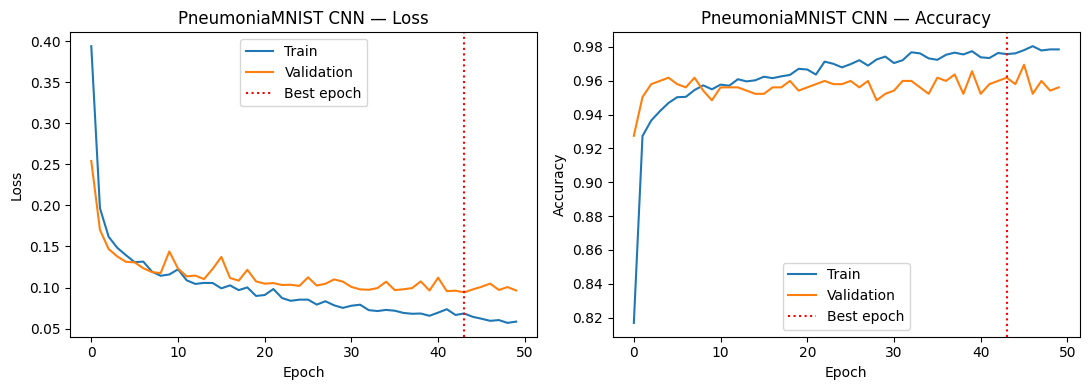

Early stopping triggered at epoch 50, best epoch: 44


In [17]:
# ── PneumoniaMNIST training curves ────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

best_epoch_pneu = int(np.argmin(cnn_pneu_history.history['val_loss']))

for ax, metric, title in zip(
    axes,
    [('loss', 'val_loss'), ('accuracy', 'val_accuracy')],
    ['Loss', 'Accuracy']
):
    train_key, val_key = metric
    ax.plot(cnn_pneu_history.history[train_key], label='Train')
    ax.plot(cnn_pneu_history.history[val_key],   label='Validation')
    ax.axvline(best_epoch_pneu, color='red', linestyle=':', linewidth=1.5, label='Best epoch')
    ax.set(xlabel='Epoch', ylabel=title,
           title=f'PneumoniaMNIST CNN — {title}')
    ax.legend()

plt.tight_layout()
plt.show()
print(f'Early stopping triggered at epoch {len(cnn_pneu_history.history["loss"])}, '
      f'best epoch: {best_epoch_pneu + 1}')


### 3.3 Smoothed Grad-CAM on chest X-rays

$$L^c_{\text{Grad-CAM}} = \text{ReLU}\!\left(\sum_k \alpha_k^c A^k\right),
\qquad \alpha_k^c = \frac{1}{HW}\sum_{i,j}\frac{\partial y^c}{\partial A^k_{ij}}$$

With `padding='same'` and no pooling, `conv1` outputs $28 \times 28 \times 16$ feature maps
— the heatmap is at full input resolution.


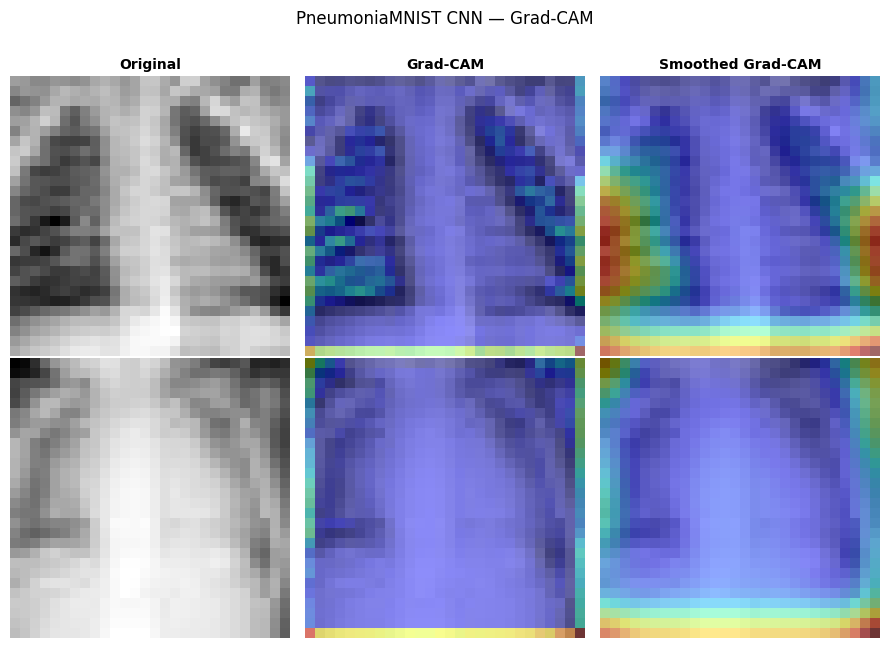

In [18]:
idx_norm_t = np.where(y_pneu_test == 0)[0][2]
idx_pneu_t = np.where(y_pneu_test == 1)[0][2]

visualise_cam(cnn_pneu, x_pneu_test, y_pneu_test,
              indices=[idx_norm_t, idx_pneu_t],
              label_map=label_map_pneu,
              title_prefix="PneumoniaMNIST CNN — ")


**Interpreting the chest X-ray heatmaps:**

- **Pneumonia (top row):** Activation concentrates in the lower lung field —
  clinically plausible, since pneumonia typically presents as consolidation
  in the lower lobes.

- **Normal (bottom row):** Activation is faint overall, but may appear at
  image edges or corners. This is a red flag — edges have no clinical meaning.
  It suggests the model may be responding to image artifacts or compression
  patterns rather than true anatomy.

- **Key lesson:** High accuracy does not mean the model looks at the right thing.
  At 28×28 resolution, anatomical detail is severely limited. A model achieving
  good accuracy on this dataset may be exploiting low-level texture differences
  rather than pathology-specific features.


---
## Summary

| Model | Dataset | Parameters | Test accuracy |
|-------|---------|------------|---------------|
| MLP (Dense 784→16→1) | MNIST 3 vs 8 | 12,577 | *(printed above)* |
| CNN (Conv→Flatten→1) | MNIST 3 vs 8 | 12,705 | *(printed above)* |
| CNN (same architecture) | PneumoniaMNIST | 12,705 | *(printed above)* |

**Key takeaways:**
- The CNN and MLP have nearly identical parameter counts — the difference is *structure*:
  16 spatial filters (CNN) vs. dense pixel-to-pixel connections (MLP).
- Early stopping monitors validation loss and restores the best weights.
- Grad-CAM produces a spatial heatmap at no extra training cost — the same gradients used in backpropagation.
- In biomedical applications, interpretability matters as much as accuracy.

**Next:** Deep-Symbolic Optimization (DSO) for learning ODEs from data.


---
## Discussion

**Exercises** — try changing one thing at a time and observe what happens:

1. Change the MLP hidden layer from 16 to 32, 64, or 128 neurons. How does test accuracy change? At what point do you stop gaining much?
2. Add a second `Dense(16, activation='relu')` layer to the MLP before the output. Does a deeper network outperform the single-layer version?
3. Replace `relu` with `sigmoid` in the MLP hidden layer. What happens to training speed and final accuracy?
4. Change the CNN from 16 filters to 8 or 32. How does accuracy and training time change?
5. Insert `MaxPooling2D((2,2))` after the Conv2D layer. How does this change the output shape and parameter count?
6. Change the batch size from 64 to 16 or 256. What do you notice about training stability and speed?
7. Change Adam's learning rate from 0.001 to 0.01 or 0.0001. What happens to the training curve in each case?
